In [67]:
import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.inspection import permutation_importance

#### 4.1) Загрузка исходных данных

In [52]:
train = pd.read_parquet("train.parquet")
validation = pd.read_parquet("validation.parquet")
test = pd.read_parquet("test.parquet")

train["created_at"] = pd.to_datetime(train["created_at"])
validation["created_at"] = pd.to_datetime(validation["created_at"])
test["created_at"] = pd.to_datetime(test["created_at"])

#### 4.2) Обучение модели

Данная функция превратит исходные данные во временной ряд количества уникальных заказов в день.

In [53]:
def make_daily_orders(df):
    daily = (
        df.groupby(df["created_at"].dt.floor("D"))["increment_id"]
          .nunique()
          .sort_index()
    )

    full_index = pd.date_range(
        daily.index.min(),
        daily.index.max(),
        freq="D"
    )

    return daily.reindex(full_index, fill_value=0)

In [72]:
train_daily = make_daily_orders(train)
val_daily = make_daily_orders(validation)
test_daily = make_daily_orders(test)

train_daily.head()

2016-07-01    447
2016-07-02    198
2016-07-03    120
2016-07-04    182
2016-07-05    114
Freq: D, Name: increment_id, dtype: int64

Данная функция превращает исходные табличные данные в набор дневных агрегированных признаков для модели.

In [73]:
def make_daily_raw_features(df):
    data = df.copy()
    data["date"] = data["created_at"].dt.floor("D")

    result = pd.DataFrame(
        index=pd.date_range(
            data["date"].min(),
            data["date"].max(),
            freq="D"
        )
    )

    numeric_cols = (
        data
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    numeric_cols = [
        col for col in numeric_cols
        if col != "increment_id"
    ]

    for col in numeric_cols:
        grouped = data.groupby("date")[col]

        result[f"{col}_mean"] = grouped.mean()
        result[f"{col}_median"] = grouped.median()
        result[f"{col}_std"] = grouped.std()
        result[f"{col}_min"] = grouped.min()
        result[f"{col}_max"] = grouped.max()
        result[f"{col}_sum"] = grouped.sum()

    categorical_cols = (
        data
        .select_dtypes(include=["object", "category", "string"])
        .columns
        .tolist()
    )

    categorical_cols = [
        col for col in categorical_cols
        if col != "increment_id"
    ]

    for col in categorical_cols:
        result[f"{col}_nunique"] = (
            data.groupby("date")[col].nunique()
        )

    result["rows_count"] = (
        data.groupby("date").size()
    )

    return result

In [56]:
all_raw = pd.concat(
    [train, validation, test],
    ignore_index=True
)

all_daily_raw_features = make_daily_raw_features(
    all_raw
)

all_daily_raw_features.head()

,price_mean,price_median,price_std,price_min,price_max,price_sum,qty_ordered_mean,qty_ordered_median,qty_ordered_std,qty_ordered_min,...,status_nunique,sku_nunique,category_name_1_nunique,sales_commission_code_nunique,payment_method_nunique,BI Status_nunique,M-Y_nunique,FY_nunique,Customer ID_nunique,rows_count
2016-07-01,1959.960238,360.0,8473.646948,1.0,96499.0,1072098.25,1.135283,1.0,0.640497,1,...,5,260,13,82,9,3,1,1,184,547
2016-07-02,4324.272692,613.0,12689.135962,1.0,96499.0,1124310.9,1.157692,1.0,0.86666,1,...,3,184,13,44,7,3,1,1,139,260
2016-07-03,1297.904762,350.0,3407.376844,1.0,33999.0,272560.0,1.257143,1.0,2.29219,1,...,4,135,10,9,6,3,1,1,98,210
2016-07-04,2599.734716,420.0,8636.18932,1.0,71999.0,595339.25,1.148472,1.0,0.541894,1,...,4,160,13,40,7,3,1,1,125,229
2016-07-05,2446.75744,435.0,9702.877717,1.0,96499.0,411055.25,1.154762,1.0,0.734016,1,...,3,130,13,19,5,3,1,1,74,168


Следующая функция собирает итоговый набор признаков для модели. Она берет временной ряд заказов series, добавляет сезонные признаки, лаги, скользящие статистики и затем присоединяет агрегированные признаки из исходного датасета.

In [74]:
def make_features(series, raw_daily_features=None):
    features = pd.DataFrame({
        "orders": series
    })

    features["day_of_week"] = features.index.dayofweek
    features["month"] = features.index.month
    features["is_weekend"] = (
        features["day_of_week"] >= 5
    ).astype(int)

    features["dow_sin"] = np.sin(
        2 * np.pi * features["day_of_week"] / 7
    )

    features["dow_cos"] = np.cos(
        2 * np.pi * features["day_of_week"] / 7
    )

    day_of_year = features.index.dayofyear

    features["year_sin"] = np.sin(
        2 * np.pi * day_of_year / 365.25
    )

    features["year_cos"] = np.cos(
        2 * np.pi * day_of_year / 365.25
    )

    for lag in [1, 7, 14, 28]:
        features[f"lag_{lag}"] = (
            features["orders"].shift(lag)
        )

    shifted_orders = features["orders"].shift(1)

    for window in [7, 28]:
        features[f"rolling_mean_{window}"] = (
            shifted_orders.rolling(window).mean()
        )

        features[f"rolling_std_{window}"] = (
            shifted_orders.rolling(window).std()
        )

    if raw_daily_features is not None:
        raw_features = (
            raw_daily_features
            .reindex(features.index)
            .copy()
        )

        raw_features = raw_features.shift(1)

        raw_features = raw_features.add_prefix("raw_")

        features = features.join(
            raw_features,
            how="left"
        )

    return features

In [75]:
train_features = make_features(
    train_daily,
    all_daily_raw_features
)

train_features = train_features.dropna(
    axis=1,
    how="all"
)

X_train = train_features.drop(columns="orders")
y_train = train_features["orders"]

print("Количество признаков:", X_train.shape[1])

Количество признаков: 68


In [77]:
model = HistGradientBoostingRegressor(
    loss="poisson",
    learning_rate=0.03,
    max_iter=500,
    max_leaf_nodes=15,
    min_samples_leaf=10,
    l2_regularization=5,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'poisson'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.03
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",500
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",15
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",10
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


Следующая функция делает рекурсивный прогноз по дням. То есть модель предсказывает один день, потом использует свой же прогноз как часть истории для следующего дня.

In [78]:
def recursive_forecast(
    model,
    history,
    forecast_dates,
    feature_columns,
    raw_daily_features
):
    history = history.copy()
    predictions = []

    for date in forecast_dates:
        temp = pd.concat([
            history,
            pd.Series(
                [np.nan],
                index=[date]
            )
        ])

        features = make_features(
            temp,
            raw_daily_features
        )

        X_date = features.loc[
            [date],
            feature_columns
        ]

        prediction = model.predict(X_date)[0]

        prediction = max(0, prediction)

        predictions.append(prediction)

        history.loc[date] = prediction

    return pd.Series(
        predictions,
        index=forecast_dates,
        name="prediction"
    )

In [79]:
val_pred = recursive_forecast(
    model=model,
    history=train_daily,
    forecast_dates=val_daily.index,
    feature_columns=X_train.columns,
    raw_daily_features=all_daily_raw_features
)

comparison = pd.DataFrame({
    "actual": val_daily,
    "prediction": val_pred
})

comparison.head()

,actual,prediction
2017-12-08,616,703.946549
2017-12-09,359,670.412949
2017-12-10,258,299.481465
2017-12-11,378,448.497089
2017-12-12,367,395.807697


In [80]:
mae_model = mean_absolute_error(
    comparison["actual"],
    comparison["prediction"]
)

rmse_model = np.sqrt(
    mean_squared_error(
        comparison["actual"],
        comparison["prediction"]
    )
)

r2_model = r2_score(
    comparison["actual"],
    comparison["prediction"]
)

print("VALIDATION")
print(f"MAE:  {mae_model:.2f}")
print(f"RMSE: {rmse_model:.2f}")
print(f"R²:   {r2_model:.3f}")

VALIDATION
MAE:  330.74
RMSE: 693.25
R²:   0.077


In [81]:
test_mae = mean_absolute_error(
    test_comparison["actual"],
    test_comparison["prediction"]
)

test_rmse = np.sqrt(
    mean_squared_error(
        test_comparison["actual"],
        test_comparison["prediction"]
    )
)

test_r2 = r2_score(
    test_comparison["actual"],
    test_comparison["prediction"]
)

print("TEST")
print(f"MAE:  {test_mae:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"R²:   {test_r2:.3f}")

TEST
MAE:  235.31
RMSE: 488.33
R²:   0.239


In [82]:
val_features = make_features(
    pd.concat([train_daily, val_daily]),
    all_daily_raw_features
)

X_val = val_features.loc[
    val_daily.index,
    X_train.columns
]

y_val = val_daily

In [83]:
perm_importance = permutation_importance(
    model,
    X_val,
    y_val,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [84]:
feature_importance = pd.DataFrame({
    "feature": X_val.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
}).sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance,std
66,raw_Customer ID_nunique,23.182406,7.308399
23,raw_qty_ordered_std,17.632744,23.417821
31,raw_grand_total_max,7.513112,1.586009
7,lag_1,7.129201,1.732428
0,day_of_week,7.038262,3.590157
56,raw_Month_sum,6.604726,4.966520
8,lag_7,5.223215,3.393119
20,raw_price_sum,4.705852,1.660754
60,raw_category_name_1_nunique,4.591496,3.008166
28,raw_grand_total_median,4.333209,1.582657


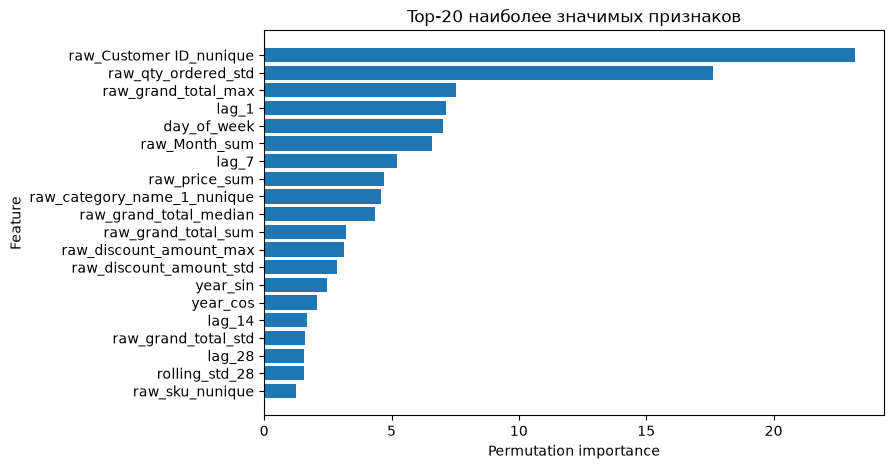

In [85]:
top_features = feature_importance.head(20).sort_values(
    "importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Permutation importance")
plt.ylabel("Feature")
plt.title("Top-20 наиболее значимых признаков")

plt.show()

#### 4.3) Вывод

По метрикам модель показывает приемлемое, но пока ограниченное качество прогноза. На validation-выборке MAE составляет 330.74, RMSE - 693.25, а R² - 0.077. Положительное значение R² означает, что модель уже лучше простого предсказания среднего, однако объясняет только небольшую часть вариативности целевого показателя.

На test-выборке качество заметно выше: MAE снизился до 235.31, RMSE - до 488.33, а R² вырос до 0.239. Это говорит о том, что на тестовом периоде модель прогнозирует стабильнее и объясняет около 24% изменчивости количества заказов.

Модель с расширенным набором признаков показала улучшение относительно обоих бейзлайнов. По сравнению с предсказанием среднего MAE снизился примерно в 1.25 раза, а RMSE - в 1.04 раза. По сравнению с сезонным бейзлайном MAE снизился в 1.04 раза, а RMSE - примерно в 1.08 раза. При этом R² стал положительным и достиг 0.077, что также свидетельствует об улучшении качества прогноза.

По результатам permutation importance наиболее значимыми оказались признаки, связанные с активностью клиентов, стоимостью заказов и недавней динамикой временного ряда. В первую очередь выделяются raw_Customer ID_nunique, raw_grand_total_max, lag_1, day_of_week, raw_price_sum, raw_grand_total_median и raw_discount_amount_max. Это показывает, что модель сильнее всего опирается на недавнее поведение заказов и характеристики исходных транзакционных данных.

Признаки lag_7 и lag_14 также вносят вклад, что подтверждает наличие недельной сезонности. Годовые сезонные компоненты year_sin и year_cos имеют гораздо меньшую важность, поэтому долгосрочная сезонность играет второстепенную роль.